In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
SELECT timestamp
FROM checker
WHERE uid NOT LIKE 'admin_%' AND timestamp IS NOT NULL
"""
df = pd.io.sql.read_sql(query, conn)

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

def categorize(hour):
    if 0 <= hour <= 3:
        return 'night'
    elif 4 <= hour <= 9:
        return 'morning'
    elif 10 <= hour <= 16:
        return 'afternoon'
    else:
        return 'evening'

df['daytime'] = df['hour'].apply(categorize)

In [5]:
pivot = df.groupby(['date', 'daytime']).size().unstack(fill_value=0)
pivot = pivot[['night', 'morning', 'afternoon', 'evening']]

In [9]:
pivot.shape

(35, 4)

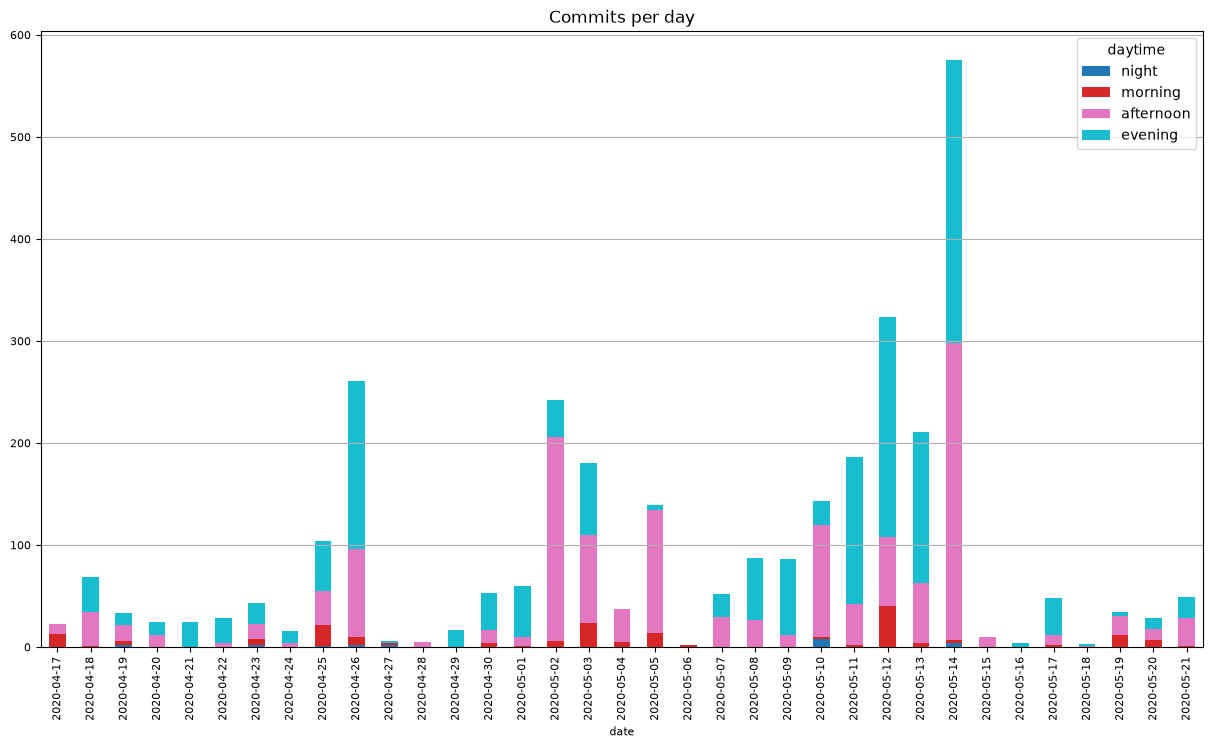

In [11]:
ax = pivot.plot.bar(
    figsize=(15, 8),
    stacked=True,
    colormap='tab10',
    title='Commits per day',
    fontsize=8,
    rot=90,
    legend=True
)
ax.grid(axis='y')
_ = ax.set_xlabel('date', fontsize=8)

In [7]:
conn.close()

Когда наши пользователи обычно коммитят: ночью, утром, днём или вечером?

Ответ: afternoon, evening

Какой день имел максимальное число коммитов и при этом вечером коммитов больше, чем днём?

Ответ: 2020-05-12